In [24]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 绘图设置
# 风格
plt.style.use('seaborn-v0_8-whitegrid')
# 全局设置
config = {'font.family':'Times New Roman', 'figure.dpi':500, 'figure.figsize':(10,8), 'axes.labelsize':20}
plt.rcParams.update(config)
# 配色
from matplotlib.colors import LinearSegmentedColormap
colors = ['#3e324a', '#475d7b', '#97c6c0', '#e26e1b', '#4df8e8'] # FireFly!
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

# 其它
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

In [ ]:
# 加载数据
data_set = []

for u in range(35, 61):
    file_name = 'shutter2/10 ' + str(u)[0] + '_' + str(u)[1] + '.csv'
    data_set.append(pd.read_csv(file_name))

In [ ]:
# 封装函数

# 定义拟合函数（用来拟合高电平和低电平的水平值）
def flat_line(x, a):
    return a * np.ones_like(x)

# 数据处理
def analysis(data):
    '''
    Input:  
    data: pd.DataFrame  

    output:  
    CH2_fall_duration  
    CH2_rise_duration  
    response_time
    '''
    # 提取数据
    time = data["Time(s)"].values
    CH1 = data["CH1(V)"].values
    CH2 = data["CH2(V)"].values


In [25]:
# 加载数据
data = pd.read_csv("shutter2/10 5_0.csv")

# 提取数据
time = data["Time(s)"].values
ch1 = data["CH1(V)"].values
ch2 = data["CH2(V)"].values

# 滤波
window_length = 31  # 窗口长度，可以根据实际情况调整
polyorder = 3       # 多项式阶数，一般为2或3
CH1 = savgol_filter(ch1, window_length, polyorder)
CH2 = savgol_filter(ch2, window_length, polyorder)

CH1 左跃变时间: -2e-07
CH1 右跃变时间: -0.05
CH2 高电平: 0.519390245440976
CH2 低电平: 0.053228579857252344
CH2 下降开始时间: -0.038598
CH2 下降结束时间: -0.024233
CH2 下降时间: 0.014365
CH2 上升开始时间: -0.02421
CH2 上升结束时间: -0.038598
CH2 上升时间: -0.014388000000000001
响应时间: -0.0385978


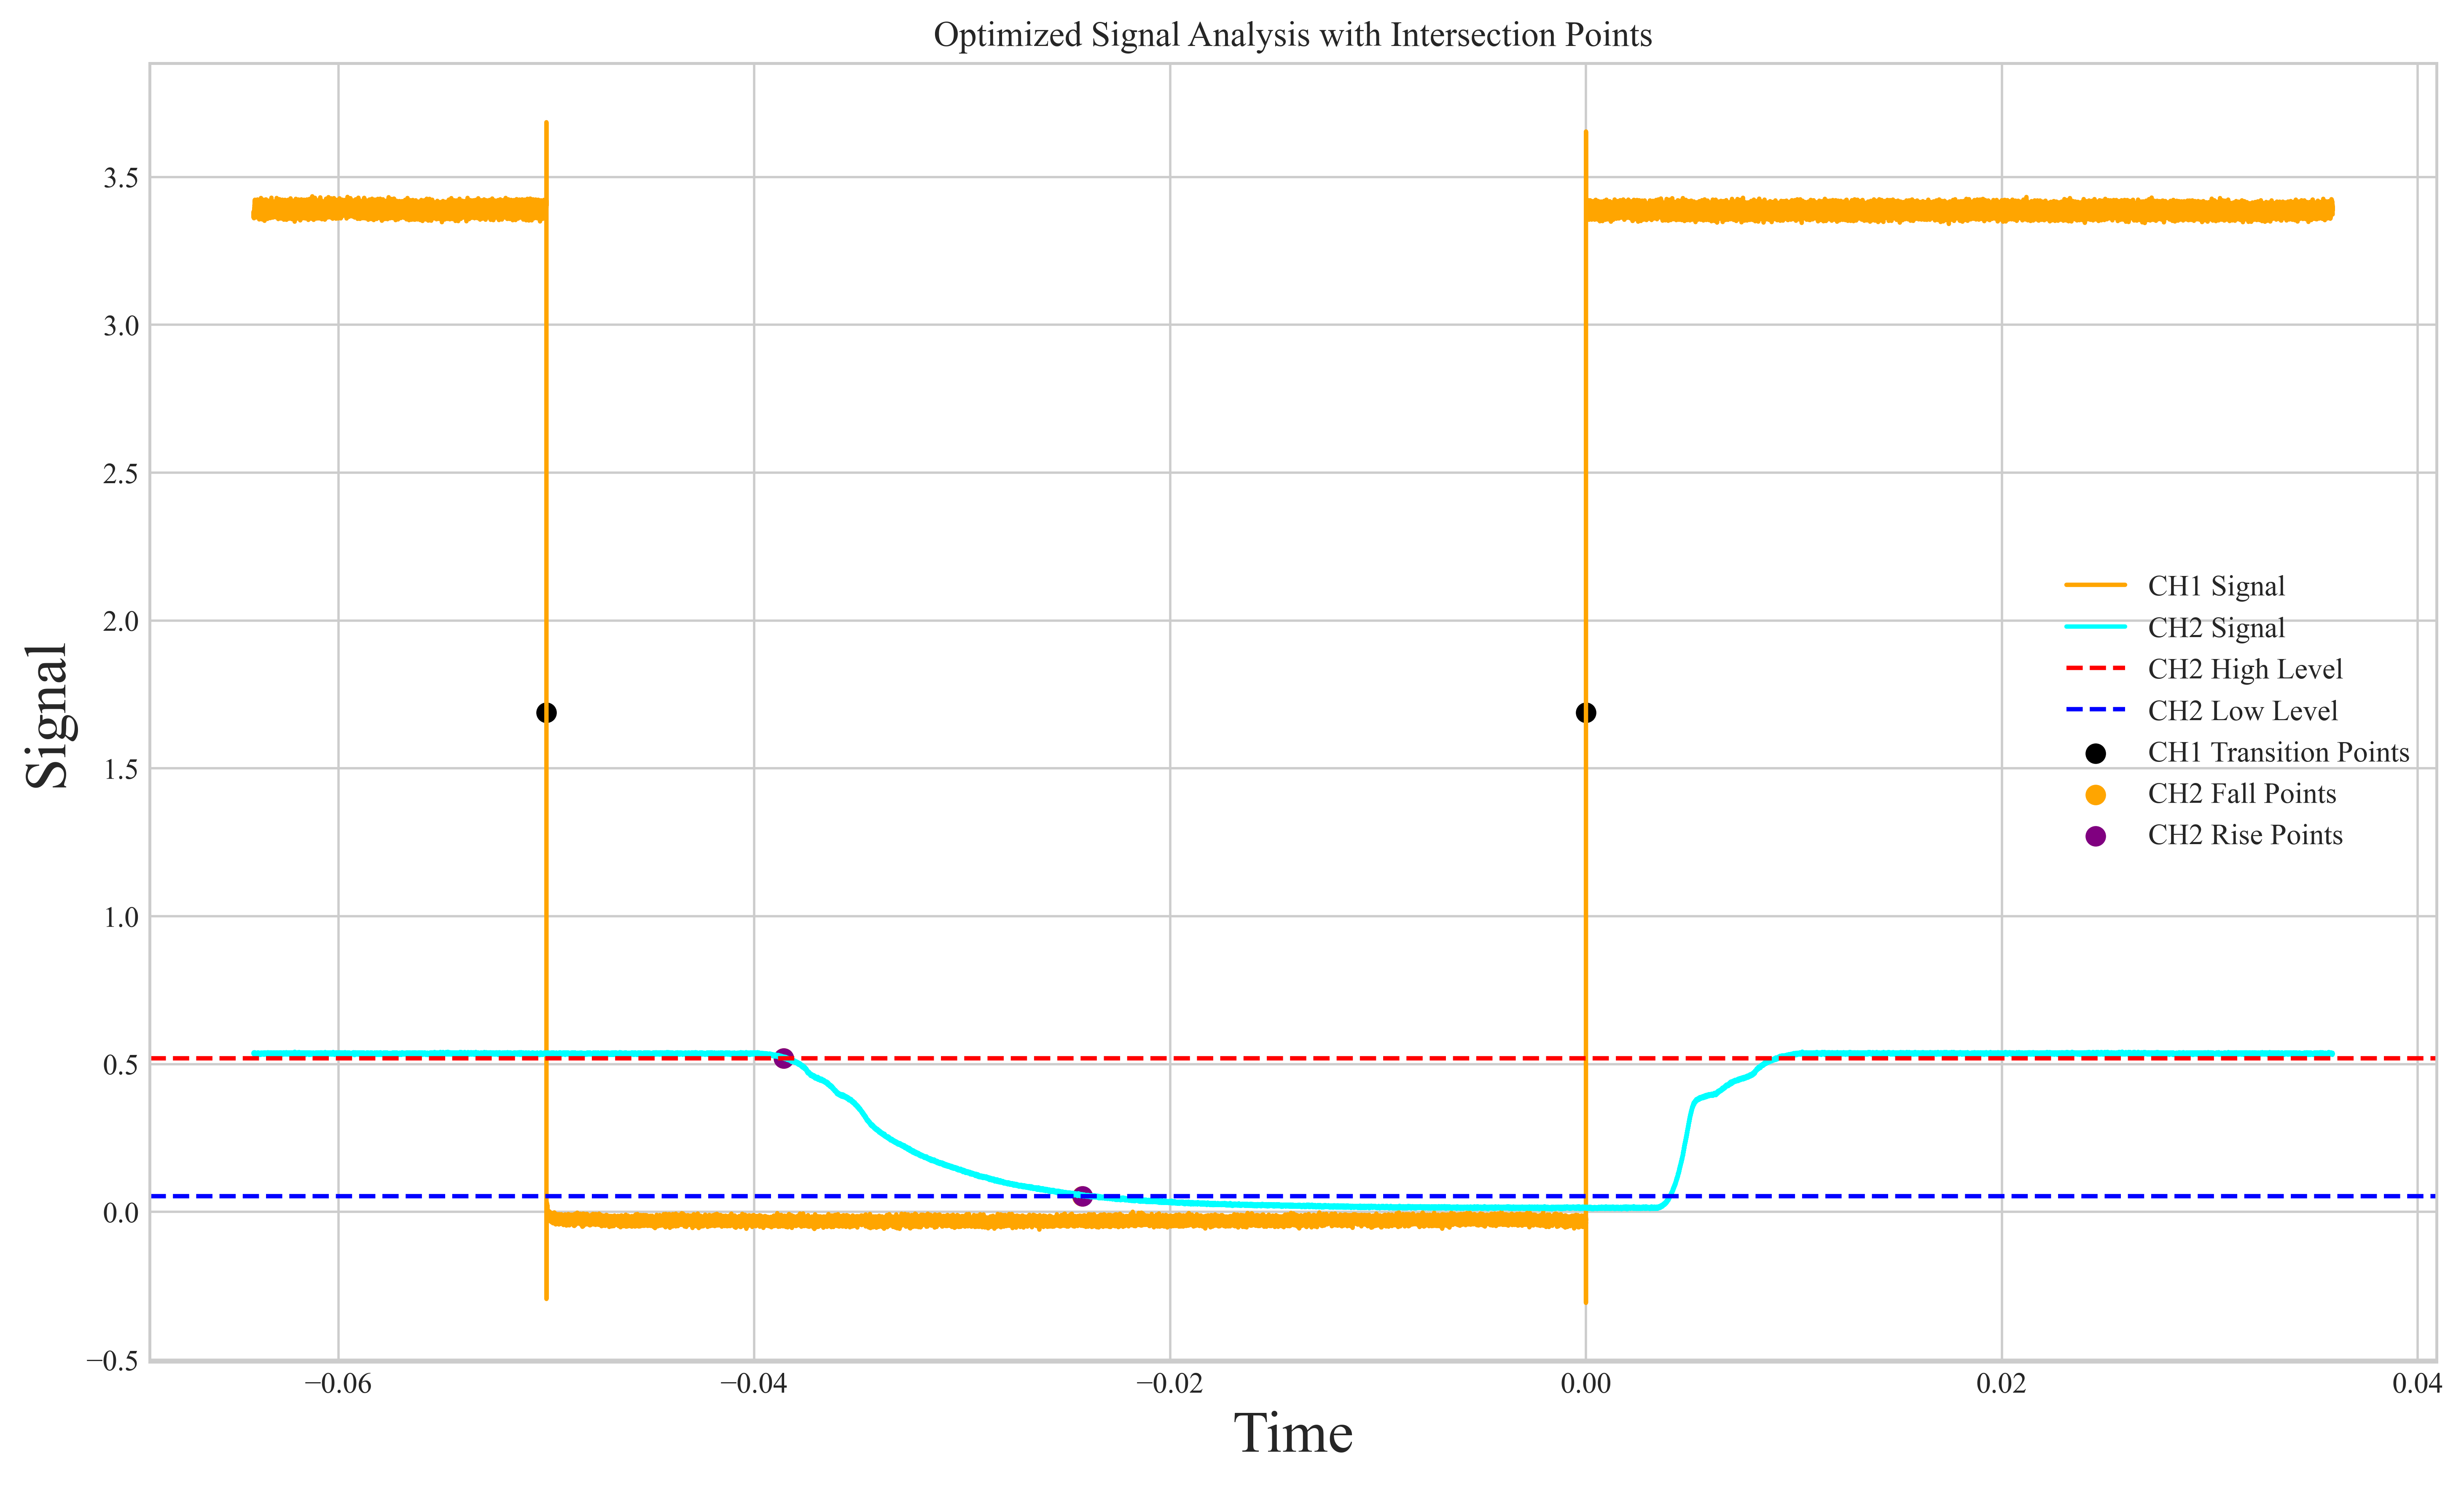

In [28]:
# 定义拟合函数（用来拟合平稳区域的高低电平值）
def flat_line(x, a):
    return a * np.ones_like(x)

# 找到 CH1 左右跃变点
CH1_threshold = (np.max(CH1) + np.min(CH1)) / 2  # 动态阈值
CH1_left_index = np.where((CH1[:-1] < CH1_threshold) & (CH1[1:] > CH1_threshold))[0][0]
CH1_right_index = np.where((CH1[:-1] > CH1_threshold) & (CH1[1:] < CH1_threshold))[0][0]
CH1_left_time = time[CH1_left_index]
CH1_right_time = time[CH1_right_index]

# 拟合 CH2 信号高低电平值
high_indices = np.where(CH2 > (np.max(CH2) + np.min(CH2)) / 2)[0]
low_indices = np.where(CH2 < (np.max(CH2) + np.min(CH2)) / 2)[0]

# 高电平拟合
popt_high, _ = curve_fit(flat_line, time[high_indices], CH2[high_indices])
CH2_high_level = popt_high[0]

# 低电平拟合
popt_low, _ = curve_fit(flat_line, time[low_indices], CH2[low_indices])
CH2_low_level = popt_low[0]

# 找到 CH2 的下降开始时间
CH2_fall_start_index = np.where((CH2[:-1] > CH2_high_level) & (CH2[1:] < CH2_high_level))[0][0]
CH2_fall_start_time = time[CH2_fall_start_index]

# 找到停止下降和开始上升时间点：通过低电平拟合直线与信号曲线交点
# 交点的计算方法
def find_intersection(x, y, level):
    """找到信号 y 与水平线 level 的交点"""
    intersections = []
    for i in range(len(y) - 1):
        if (y[i] > level and y[i + 1] < level) or (y[i] < level and y[i + 1] > level):
            # 线性插值计算交点
            t = (level - y[i]) / (y[i + 1] - y[i])
            intersection_time = x[i] + t * (x[i + 1] - x[i])
            intersections.append(intersection_time)
    return intersections

# 找低电平交点
low_intersections = find_intersection(time, CH2, CH2_low_level)

# 确定停止下降和开始上升的时间点
if len(low_intersections) >= 2:
    CH2_fall_end_time = low_intersections[0]  # 第一个交点为停止下降时间点
    CH2_rise_start_time = low_intersections[2]  # 第二个交点为开始上升时间点
else:
    raise ValueError("未找到低电平的两个交点，请检查数据质量")

# 计算下降时间和上升时间
CH2_fall_duration = CH2_fall_end_time - CH2_fall_start_time

# 找到 CH2 上升结束时间
CH2_rise_end_index = np.where((CH2[:-1] < CH2_high_level) & (CH2[1:] > CH2_high_level))[0][0]
CH2_rise_end_time = time[CH2_rise_end_index]
CH2_rise_duration = CH2_rise_end_time - CH2_rise_start_time

# 计算响应时间
response_time = CH2_fall_start_time - CH1_left_time

# 输出结果
print("CH1 左跃变时间:", CH1_left_time)
print("CH1 右跃变时间:", CH1_right_time)
print("CH2 高电平:", CH2_high_level)
print("CH2 低电平:", CH2_low_level)
print("CH2 下降开始时间:", CH2_fall_start_time)
print("CH2 下降结束时间:", CH2_fall_end_time)
print("CH2 下降时间:", CH2_fall_duration)
print("CH2 上升开始时间:", CH2_rise_start_time)
print("CH2 上升结束时间:", CH2_rise_end_time)
print("CH2 上升时间:", CH2_rise_duration)
print("响应时间:", response_time)

# 可视化信号及标记点
plt.figure(figsize=(14, 8))
plt.plot(time, CH1, label="CH1 Signal", color="orange")
plt.plot(time, CH2, label="CH2 Signal", color="cyan")
plt.axhline(CH2_high_level, color="red", linestyle="--", label="CH2 High Level")
plt.axhline(CH2_low_level, color="blue", linestyle="--", label="CH2 Low Level")
plt.scatter([CH1_left_time, CH1_right_time], [CH1_threshold, CH1_threshold], color="black", label="CH1 Transition Points")
plt.scatter([CH2_fall_start_time, CH2_fall_end_time], [CH2_high_level, CH2_low_level], color="orange", label="CH2 Fall Points")
plt.scatter([CH2_rise_start_time, CH2_rise_end_time], [CH2_low_level, CH2_high_level], color="purple", label="CH2 Rise Points")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Signal")
plt.title("Optimized Signal Analysis with Intersection Points")
plt.show()
